In [ ]:
!pip install -q "psycopg[binary]" --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.6/213.6 kB 19.0 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata
database_url = userdata.get('Analyst_NeonDB_Postgresql_server')

In [ ]:
import psycopg
conn = psycopg.connect(database_url)
print("Connected to Neon successfully.")

with conn.cursor() as cur:
  cur.execute("SELECT version();")
  print(cur.fetchone()[0])

from sqlalchemy import create_engine
engine = create_engine(database_url)


Connected to Neon successfully.
PostgreSQL 18.6 (c5250a2) on aarch64-unknown-linux-gnu, compiled by gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0, 64-bit


In [ ]:
import pandas as pd

In [ ]:
query = """
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public'
ORDER BY table_name;
"""

tables = pd.read_sql(query, engine)
tables

,table_name
0,customers
1,geolocation
2,order_items
3,order_payments
4,order_reviews
5,orders
6,product_category
7,products
8,sellers


In [ ]:
# Customer count

query = """
SELECT
    COUNT(*) AS customer_records,
    COUNT(DISTINCT customer_id) AS unique_customer_ids,
    COUNT(DISTINCT customer_unique_id) AS unique_customers
FROM customers;
"""

customer_counts = pd.read_sql(query, engine)

customer_counts

,customer_records,unique_customer_ids,unique_customers
0,99441,99441,96096


In [ ]:
# Orders per customer

query = """
SELECT
    c.customer_unique_id,
    COUNT(DISTINCT o.order_id) AS order_count
FROM customers AS c
JOIN orders AS o
    ON c.customer_id = o.customer_id
GROUP BY c.customer_unique_id
ORDER BY order_count DESC;
"""

orders_per_customer = pd.read_sql(query, engine)

orders_per_customer

,customer_unique_id,order_count
0,8d50f5eadf50201ccdcedfb9e2ac8455,17
1,3e43e6105506432c953e165fb2acf44c,9
2,1b6c7548a2a1f9037c1fd3ddfed95f33,7
3,6469f99c1f9dfae7733b25662e7f1782,7
4,ca77025e7201e3b30c44b472ff346268,7
...,...,...
96091,041eaf07c71e1d56b489dff63a270e6a,1
96092,041eb6136ede40c0bd0f31372d7f481e,1
96093,041ecd93f392ac99f53809f2fc47c7fb,1
96094,041fb341560d3bb7036cfab81cfbf063,1


In [ ]:
orders_per_customer["order_count"].describe()

,order_count
count,96096.000000
mean,1.034809
std,0.214384
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,17.000000


In [ ]:
# Repeat customers

query = """
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS order_count
    FROM customers AS c
    JOIN orders AS o
        ON c.customer_id = o.customer_id
    GROUP BY c.customer_unique_id
)

SELECT
    CASE
        WHEN order_count = 1 THEN 'One-time'
        ELSE 'Repeat'
    END AS customer_type,

    COUNT(*) AS customers,

    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
        2
    ) AS customer_share_pct

FROM customer_orders

GROUP BY 1
ORDER BY customers DESC;
"""

customer_type = pd.read_sql(query, engine)

customer_type

,customer_type,customers,customer_share_pct
0,One-time,93099,96.88
1,Repeat,2997,3.12


In [ ]:
query = """
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS order_count
    FROM customers AS c
    JOIN orders AS o
        ON c.customer_id = o.customer_id
    GROUP BY c.customer_unique_id
)

SELECT
    order_count,
    COUNT(*) AS customers

FROM customer_orders

GROUP BY order_count

ORDER BY order_count;
"""

purchase_frequency = pd.read_sql(query, engine)

purchase_frequency

,order_count,customers
0,1,93099
1,2,2745
2,3,203
3,4,30
4,5,8
5,6,6
6,7,3
7,9,1
8,17,1


In [ ]:
# top customers

query = """
SELECT
    c.customer_unique_id,
    COUNT(DISTINCT o.order_id) AS order_count
FROM customers AS c
JOIN orders AS o
    ON c.customer_id = o.customer_id
GROUP BY c.customer_unique_id
ORDER BY order_count DESC
LIMIT 20;
"""

top_frequency_customers = pd.read_sql(query, engine)

top_frequency_customers

,customer_unique_id,order_count
0,8d50f5eadf50201ccdcedfb9e2ac8455,17
1,3e43e6105506432c953e165fb2acf44c,9
2,ca77025e7201e3b30c44b472ff346268,7
3,6469f99c1f9dfae7733b25662e7f1782,7
4,1b6c7548a2a1f9037c1fd3ddfed95f33,7
5,f0e310a6839dce9de1638e0fe5ab282a,6
6,12f5d6e1cbf93dafd9dcc19095df0b3d,6
7,63cfc61cee11cbe306bff5857d00bfe4,6
8,47c1a3033b8b77b3ab6e109eb4d5fdf3,6
9,dc813062e0fc23409cd255f7f53c7074,6


In [ ]:
# top monetary value

query = """
SELECT
    c.customer_unique_id,

    COUNT(DISTINCT o.order_id) AS order_count,

    SUM(oi.price) AS total_spend,

    AVG(oi.price) AS average_item_value

FROM customers AS c

JOIN orders AS o
    ON c.customer_id = o.customer_id

JOIN order_items AS oi
    ON o.order_id = oi.order_id

GROUP BY c.customer_unique_id

ORDER BY total_spend DESC
LIMIT 20;
"""

top_value_customers = pd.read_sql(query, engine)

top_value_customers

,customer_unique_id,order_count,total_spend,average_item_value
0,0a0a92112bd4c708ca5fde585afaa872,1,13440.00,1680.00
1,da122df9eeddfedc1dc1f5349a1a690c,2,7388.00,3694.00
2,763c8b1c9c68a0229c42c9fc6f662b93,1,7160.00,1790.00
3,dc4802a71eae9be1dd28f5d788ceb526,1,6735.00,6735.00
4,459bef486812aa25204be022145caa62,1,6729.00,6729.00
5,ff4159b92c40ebe40454e3e6a7c35ed6,1,6499.00,6499.00
6,4007669dec559734d6f53e029e360987,1,5934.60,989.10
7,eebb5dda148d3893cdaf5b5ca3040ccb,1,4690.00,4690.00
8,5d0a2980b292d049061542014e8960bf,1,4599.90,2299.95
9,48e1ac109decbb87765a3eade6854098,1,4590.00,4590.00


In [ ]:
# Customer average order value

query = """
SELECT
    c.customer_unique_id,

    COUNT(DISTINCT o.order_id) AS order_count,

    SUM(oi.price) AS total_spend,

    SUM(oi.price)
        / COUNT(DISTINCT o.order_id) AS customer_aov

FROM customers AS c

JOIN orders AS o
    ON c.customer_id = o.customer_id

JOIN order_items AS oi
    ON o.order_id = oi.order_id

GROUP BY c.customer_unique_id

ORDER BY customer_aov DESC
LIMIT 20;
"""

customer_aov = pd.read_sql(query, engine)

customer_aov

,customer_unique_id,order_count,total_spend,customer_aov
0,0a0a92112bd4c708ca5fde585afaa872,1,13440.00,13440.00
1,763c8b1c9c68a0229c42c9fc6f662b93,1,7160.00,7160.00
2,dc4802a71eae9be1dd28f5d788ceb526,1,6735.00,6735.00
3,459bef486812aa25204be022145caa62,1,6729.00,6729.00
4,ff4159b92c40ebe40454e3e6a7c35ed6,1,6499.00,6499.00
5,4007669dec559734d6f53e029e360987,1,5934.60,5934.60
6,eebb5dda148d3893cdaf5b5ca3040ccb,1,4690.00,4690.00
7,5d0a2980b292d049061542014e8960bf,1,4599.90,4599.90
8,48e1ac109decbb87765a3eade6854098,1,4590.00,4590.00
9,a229eba70ec1c2abef51f04987deb7a5,1,4400.00,4400.00


In [ ]:
# Customer acquisition over time (Monthly)

query = """
WITH first_purchase AS (

    SELECT
        c.customer_unique_id,
        MIN(o.order_purchase_timestamp::timestamp) AS first_purchase_date

    FROM customers AS c

    JOIN orders AS o
        ON c.customer_id = o.customer_id

    GROUP BY c.customer_unique_id
)

SELECT
    DATE_TRUNC('month', first_purchase_date::timestamp) AS month,
    COUNT(*) AS new_customers

FROM first_purchase

GROUP BY 1

ORDER BY 1;
"""

new_customers = pd.read_sql(query, engine)

new_customers

,month,new_customers
0,2016-09-01,4
1,2016-10-01,321
2,2016-12-01,1
3,2017-01-01,764
4,2017-02-01,1752
5,2017-03-01,2636
6,2017-04-01,2352
7,2017-05-01,3596
8,2017-06-01,3139
9,2017-07-01,3894


In [ ]:
import plotly.express as px

fig = px.line(new_customers, x='month', y='new_customers',
              title='Monthly New Customer Acquisition Over Time',
              labels={'month': 'Month', 'new_customers': 'Number of New Customers'})
fig.update_xaxes(tickangle=45)
fig.update_layout(hovermode='x unified')
fig.show()

## RFM Analysis
Data-driven customer segmentation technique that evaluates clients based on three quantitative factors: Recency, Frequency, and Monetary value

The Three Core Dimensions:
- **Recency (R)**: How many days have passed since a customer's last purchase. => Lower numbers mean higher engagement.
- **Frequency (F)**: The total number of transactions or purchases a customer has made. => Higher counts indicate greater loyalty.
- **Monetary Value (M)**: The total amount of money a customer has spent over a given period. => Higher totals represent more valuable revenue sources.


How Scoring and Segmentation WorkScoring:
- Each customer is ranked from 1 to 5 (or 0 to 9) for each of the three categories.
- Combining Scores: A high score like 555 indicates a top-tier champion customer, whereas a low score like 111 highlights an inactive or lost buyer.
- Grouping: Companies cluster these scores into actionable segments—such as "Loyal Customers," "At Risk," or "Hibernating"—to tailor specific promotional offers

In [ ]:
query = """
WITH customer_metrics AS (

    SELECT
        c.customer_unique_id,

        MAX(o.order_purchase_timestamp::timestamp) AS last_purchase_date,

        COUNT(DISTINCT o.order_id) AS frequency,

        SUM(oi.price) AS monetary

    FROM customers AS c

    JOIN orders AS o
        ON c.customer_id = o.customer_id

    JOIN order_items AS oi
        ON o.order_id = oi.order_id

    GROUP BY c.customer_unique_id
),

reference_date AS (

    SELECT
        MAX(order_purchase_timestamp::timestamp) AS max_order_date
    FROM orders
)

SELECT
    cm.customer_unique_id,

    EXTRACT(
        DAY FROM (
            rd.max_order_date - cm.last_purchase_date
        )
    ) AS recency,

    cm.frequency,

    cm.monetary

FROM customer_metrics AS cm

CROSS JOIN reference_date AS rd;
"""

rfm = pd.read_sql(query, engine)
rfm

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,160.0,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163.0,1,18.90
2,0000f46a3911fa3c0805444483337064,585.0,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,369.0,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,336.0,1,180.00
...,...,...,...,...
95415,fffcf5a5ff07b0908bd4e2dbc735a684,495.0,1,1570.00
95416,fffea47cd6d3cc0a88bd621562a9d061,310.0,1,64.89
95417,ffff371b4d645b6ecea244b27531430a,617.0,1,89.90
95418,ffff5962728ec6157033ef9805bacc48,168.0,1,115.00


In [ ]:
rfm.describe()

,recency,frequency,monetary
count,95420.000000,95420.000000,95420.000000
mean,287.128118,1.034018,142.440198
std,153.157768,0.211234,217.656355
min,44.000000,1.000000,0.850000
25%,163.000000,1.000000,47.900000
50%,268.000000,1.000000,89.900000
75%,396.000000,1.000000,155.000000
max,772.000000,16.000000,13440.000000


In [ ]:
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [ ]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

rfm

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,160.0,1,129.90,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163.0,1,18.90,4,1,1,411
2,0000f46a3911fa3c0805444483337064,585.0,1,69.00,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,369.0,1,25.99,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,336.0,1,180.00,2,1,5,215
...,...,...,...,...,...,...,...,...
95415,fffcf5a5ff07b0908bd4e2dbc735a684,495.0,1,1570.00,1,5,5,155
95416,fffea47cd6d3cc0a88bd621562a9d061,310.0,1,64.89,3,5,2,352
95417,ffff371b4d645b6ecea244b27531430a,617.0,1,89.90,1,5,3,153
95418,ffff5962728ec6157033ef9805bacc48,168.0,1,115.00,4,5,4,454


In [ ]:
# Segmenting customers

def segment_customer(row):

    r = row["R_score"]
    f = row["F_score"]
    m = row["M_score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 4 and f >= 3:
        return "Loyal Customers"

    elif r >= 4 and f <= 2:
        return "Recent Customers"

    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk High Value"

    elif r <= 2:
        return "Inactive"

    else:
        return "Developing"

rfm["segment"] = rfm.apply(segment_customer, axis=1)
rfm["segment"].value_counts()
rfm.head(5)

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,160.0,1,129.90,4,1,4,414,Recent Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163.0,1,18.90,4,1,1,411,Recent Customers
2,0000f46a3911fa3c0805444483337064,585.0,1,69.00,1,1,2,112,Inactive
3,0000f6ccb0745a6a4b88665a16c9f078,369.0,1,25.99,2,1,1,211,Inactive
4,0004aac84e0df4da2b147fca70cf8255,336.0,1,180.00,2,1,5,215,Inactive


In [ ]:
segment_summary = (
    rfm
    .groupby("segment")
    .agg(
        customers=("customer_unique_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        total_monetary=("monetary", "sum")
    )
    .sort_values("total_monetary", ascending=False)
)

segment_summary

,customers,avg_recency,avg_frequency,avg_monetary,total_monetary
segment,,,,,
At Risk High Value,13486,443.676183,1.072371,216.869634,2924703.89
Developing,19126,269.684043,1.035658,134.391737,2570376.36
Inactive,24490,445.656717,1.005390,103.241698,2528389.18
Recent Customers,15335,139.687317,1.000000,140.309217,2151641.85
Champions,6651,140.100286,1.174861,277.028752,1842518.23
Loyal Customers,16332,138.888440,1.017940,96.376083,1574014.19


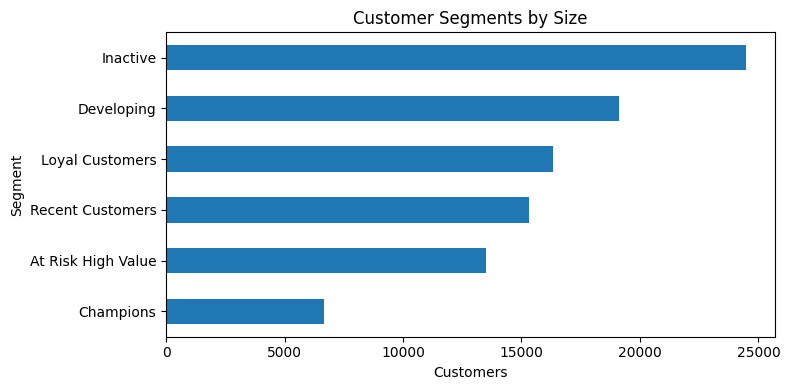

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))

segment_summary["customers"].sort_values().plot(
    kind="barh"
)

plt.xlabel("Customers")
plt.ylabel("Segment")
plt.title("Customer Segments by Size")

plt.tight_layout()
plt.show()

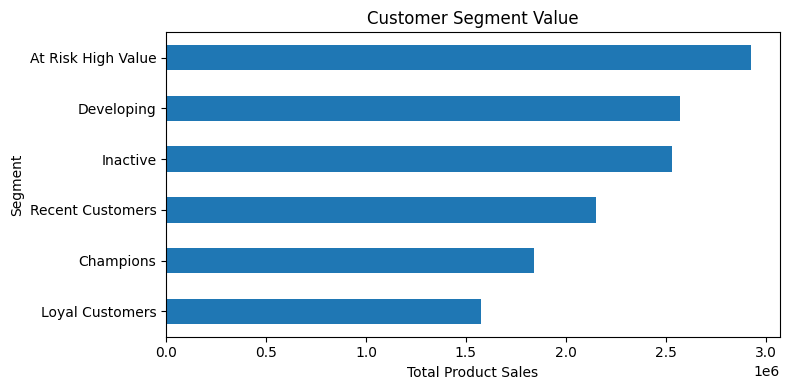

In [ ]:
plt.figure(figsize=(8, 4))

segment_summary["total_monetary"].sort_values().plot(
    kind="barh"
)

plt.xlabel("Total Product Sales")
plt.ylabel("Segment")
plt.title("Customer Segment Value")

plt.tight_layout()
plt.show()

In [ ]:
# Are repeat customers economically important, or is the marketplace predominantly acquisition-driven?

query = """
WITH customer_metrics AS (

    SELECT
        c.customer_unique_id,

        COUNT(DISTINCT o.order_id) AS orders,

        SUM(oi.price::numeric) AS total_spend

    FROM customers AS c

    JOIN orders AS o
        ON c.customer_id = o.customer_id

    JOIN order_items AS oi
        ON o.order_id = oi.order_id

    GROUP BY c.customer_unique_id
)

SELECT
    CASE
        WHEN orders = 1 THEN 'One-time'
        ELSE 'Repeat'
    END AS customer_type,

    COUNT(*) AS customers,

    AVG(total_spend) AS avg_customer_spend,

    SUM(total_spend) AS total_sales

FROM customer_metrics

GROUP BY 1

ORDER BY total_sales DESC;
"""

repeat_economics = pd.read_sql(query, engine)
repeat_economics

,customer_type,customers,avg_customer_spend,total_sales
0,One-time,92507,138.674390,12828351.84
1,Repeat,2913,262.029475,763291.86
